# **Capstone project: Providing data-driven suggestions for HR**

## Section 1. Introuction





This project, part of the Google Advanced Data Analytics course, focuses on analyzing employee attrition at Salifort Motors. The goal is to identify key factors contributing to employee resignations and develop predictive models to help the company retain its workforce. The project involves data cleaning, exploratory data analysis, feature engineering, and model building using logistic regression, random forest, and XGBoost. The results are evaluated using various performance metrics, and the best model is identified for deployment.

### Business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They have refered to data analytics professionals and ask them to provide data-driven suggestions based on their understanding of the data. They have the following question: **what’s likely to make an employee leave the company?**


**Key stakeholders**

Key stakeholders for this project are the Salifort Leadership Team, HR Team and the Data Analyst Team

**Key Objective**

The primary objective of this analysis is to develop a predictive model for employee attrition using HR data. Given that high turnover significantly impacts Salifort's bottom line—particularly through the costs of recruitment and talent development—this project aims to identify the key drivers of departure. By leveraging these insights, we can implement targeted retention strategies that enhance job satisfaction and mitigate the high costs and operational disruptions associated with recruitment and onboarding.

**Relevant resources utilized**

This project uses Coursera Course Materials and Labs, Python and Python Documentation. Gemini Code Assist and Visual Studio Code (VS Code) IntelliSense

**Ethical considerations**

The dataset appears to be free of Personally Identifiable Information (PII), and the scope of this analysis is strictly limited to aggregate trends rather than individual-level data. However, several ethical and procedural points require confirmation from the data owners:

* Was the anonymity and privacy of the data subjects maintained throughout the collection process?
* Was informed consent obtained from all participants prior to the survey?
* Did employees explicitly consent to their data being used for predictive modeling to inform corporate policy, and what degree of agency did they have over its use?"

### Data Source, Description and Limitations

*Results from the HR survey contain 15,000 rows and 10 columns for the variables listed below. This data has already been downloaded and provided (HR_capstone_dataset.csv) . For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).*

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

**Data Limitations:**

1. The current dataset lacks several key variables that could provide a more comprehensive view of employee turnover:

    * **Demographics**: Age, gender, and parental status (to identify at-risk groups).

    * **Upward feedback**:  Score where employees rate their manager's performance

    * **Total Rewards**: Historical bonus data and benefit package comparisons.

    * **Market Benchmarks**: Market salary parity by role and department.

    * **Geographic Context**: Employee location to account for regional market conditions.

    * **Exit Insights**: Data on external counter-offers provided during exit interviews.

    * **Temporal and Seasonal Features**: Temporal variables, such as the month of departure, to account for seasonality (this is critical for identifying recurring trends, such as elevated attrition rates often observed in the months immediately following annual bonus distributions or performance review cycles). 
    * **Other Temporal Variables**: Specific year(s) of data collection,to determine if the timeframe includes any anomaly years—such as the 2020-2021 pandemic period—as these global events could introduce atypical attrition patterns that may not represent standard market conditions

2. The absence of critical variables introduces a risk of omitted variable bias, which can lead to skewed results or the misrepresentation of specific employee cohorts. Specifically, the lack of demographic data makes it impossible to verify the representativeness of the sample regarding gender parity or age distribution, potentially limiting the model's generalizability.

3. The absence of temporal and seasonal features limits the granularity of the data, hindering our ability to perform longitudinal analyses or isolate specific seasonal drivers of attrition.

### Import Packages and Load Data

The following section imports the necessary libraries and modules required for the analysis.

In [297]:
# Import packages


# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import plotly.express as px


# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# Packages for statistics
import statsmodels.api as sm
from scipy import stats

# Import packages for data modeling

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from xgboost import XGBRegressor
# This is the function that helps plot feature importance
from xgboost import plot_importance
from sklearn.tree import plot_tree

# # This module lets us save our models once we fit them.
import pickle
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

### Load dataset

The following code loads the data, by reading the csv file, and displays the first 5 rows


In [298]:
# Load dataset into a dataframe
df_raw = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df_raw.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Section 2. Data Exploration (Initial EDA and data cleaning)

This section encompasses a thorough exploratory data analysis (EDA) and data cleaning phase. We begin by standardizing column names and correcting misspellings for consistency. The dataset is then checked for missing values and duplicate records, with duplicates being removed to ensure data quality. We also perform outlier detection on the 'tenure' variable using boxplots. The EDA continues with a series of visualizations, including histograms to understand the distribution of variables for employees who left versus those who stayed, and boxplots to compare key metrics across these two groups. Furthermore, we analyze feature trends over time using line charts and explore relationships between satisfaction, evaluation, and workload using scatterplots. This multi-faceted approach helps identify the primary drivers of employee attrition, such as burnout and lack of career advancement, before proceeding to model development

### Basic Data Information and Descriptive Statistics

**Basic Information**

The code below gathers information about the dataset, such as the number of rows and columns, data types of each column, and the presence of any missing values. This is crucial for understanding the structure of the data and identifying any potential issues that may need to be addressed during data cleaning and preprocessing.

In [299]:
# Gather basic information about the data
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


There are a total of 14999 rows and 10 columns. We have a mixture of numeric (int64 or float64) and categorical variables. We also have no missing values, which is good news.

**Rename columns**

The code below renames the columns to be more readable and easier to work with. It also fixes misspellings and shorten names where appropriate

In [300]:
# Rename columns as needed
df_raw.rename(columns={"last_evaluation":"latest_evaluation_score",
                    "Work_accident":"work_accident", 
                    "number_project":"projects_contributed",
                    "Department":"department",
                    "time_spend_company":"tenure",
                   "average_montly_hours":"average_monthly_hours",
                   "promotion_last_5years":"promoted_in_last_5_years"
                   },
           inplace=True)
# Display all column names after the update
df_raw.columns

Index(['satisfaction_level', 'latest_evaluation_score', 'projects_contributed',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promoted_in_last_5_years', 'department', 'salary'],
      dtype='object')

**Descriptive Statistics**

The code below gathers descriptive statistics about the dataset, including measures of central tendency and dispersion for numerical columns, as well as counts and unique values for categorical columns.

In [301]:
# Gather descriptive statistics about the data
df_raw.describe(include='all')

,satisfaction_level,latest_evaluation_score,projects_contributed,average_monthly_hours,tenure,work_accident,left,promoted_in_last_5_years,department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN



* The average evaluation score is 0.72, with a minimum of 0.36 and a maximum of 1.00. 

* The average number of projects contributed to is 3, with a minimum of 2 and a maximum of 7.

* All employees worked a minimum of 96 hours per month and a maximum of 310 hours per month. The average monthly hours worked is 201. 
    * This is quite surprisingly **high** given the industry average of 171 (42.8 * 4) for USA. Source: [BLS.gov](https://www.bls.gov/iag/tgs/iagauto.htm#:~:text=Table_title:%20Average%20Weekly%20Hours%20%2D%2D%20Not%20Seasonally,2025:%2042.8%20%7C%2012%2Dmonth%20changes::%20(p)1.8%20%7C)

* The average tenure of employees is 3.5 years, with a minimum of 2 years and a maximum of 10 years. 
    * There is a noticeable discrepancy between the mean and the median of tenure. Additionally, we observe a substantial gap between the 75th percentile and the maximum value. Specifically, while the interquartile range (25th to 75th percentile) shows only a 1-point increase, there is a significant 6-point jump from the 75th percentile to the maximum. These observations strongly suggest the presence of outliers skewing the data.

* 2.1% of employees were promoted in the last 5 years, while <span style="color:red">97.9%</span> were not promoted.

* 14.5% of employees had a work accident, while 85.5% did not have a work accident.

* The most common department is sales
* The most frequent salary level is low.


### Data Cleaning

**Confirming no missing values are present**

The code below confirms that there are no missing values in the data.

In [302]:
# Check for missing values
df_raw.isna().sum()

satisfaction_level          0
latest_evaluation_score     0
projects_contributed        0
average_monthly_hours       0
tenure                      0
work_accident               0
left                        0
promoted_in_last_5_years    0
department                  0
salary                      0
dtype: int64

None of the columns have any missing values

**Checking for duplicates**

The code below checks for any duplicates in the data

In [303]:
# Check for duplicates

print(f"There are a total of {df_raw.duplicated().sum()} duplicate rows in the dataset.")

There are a total of 3008 duplicate rows in the dataset.


The code below displays some of the rows with duplicate values

In [304]:
# Inspect some rows containing duplicates as needed

# Checking the first 1500 rows for duplicates and sorting by satisfaction level to make it easier to visualize
df_raw.iloc[:1500,][df_raw.iloc[:1500,].duplicated(keep=False)].sort_values("satisfaction_level")

,satisfaction_level,latest_evaluation_score,projects_contributed,average_monthly_hours,tenure,work_accident,left,promoted_in_last_5_years,department,salary
178,0.37,0.51,2,127,3,0,1,0,sales,medium
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
28,0.41,0.46,2,128,3,0,1,0,accounting,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1292,0.41,0.52,2,132,3,0,1,0,RandD,low
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
9,0.42,0.53,2,142,3,0,1,0,sales,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
23,0.46,0.57,2,139,3,0,1,0,sales,low
396,0.46,0.57,2,139,3,0,1,0,sales,low


In [305]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df = df_raw.drop_duplicates()
# Display shape of the dataframe after dropping duplicates
df.shape

(11991, 10)

**Checking for outliers in the Tenure Column**

As mentioned above, we suspect the Tenure variable to have outliers. The code below checks for this

Text(0.5, 0.98, 'Figure 2.0: Distribution of Tenure to Check for Outliers')

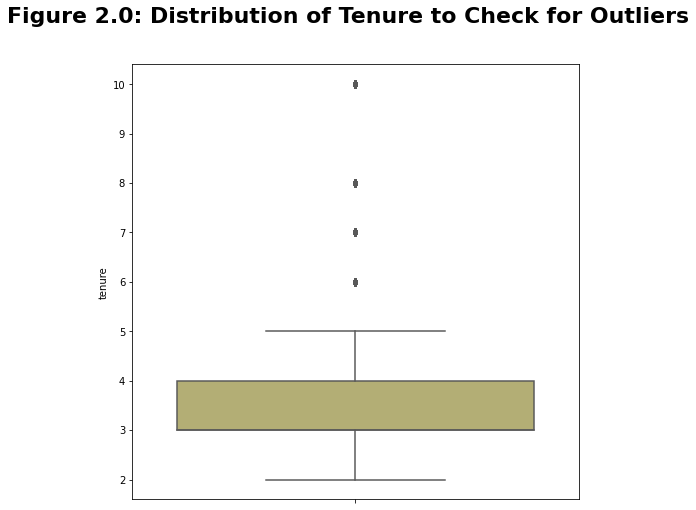

In [306]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers

fig, axes = plt.subplots(figsize=(8,8))
sns.boxplot(y=df["tenure"],color='darkkhaki')
fig.suptitle("Figure 2.0: Distribution of Tenure to Check for Outliers", fontsize=22, fontweight='bold')

We can see that the tenure variable has a couple of outliers, with the maximum tenure being 10 years. We can check for frequency of tenure values to see how many of them are outliers. 
We will define outliers as any tenure value that is greater than 1.5 times the interquartile range (IQR) for this variable.

The code below checks for the number of such values; we will only check for values greater than the upper bound since we donot see any outliers on the lower end of the boxplot

In [307]:
# Determine the number of rows containing outliers
# Any observations that are more than 1.5 IQR below Q1 or more than 1.5 IQR above Q3 are considered outliers.

# Calculate 25th percentile of tenure
percentile25 = df['tenure'].quantile(0.25)
# Calculate 75th percentile of tenure
percentile75 = df['tenure'].quantile(0.75)
# Calculate IQR
iqr = percentile75 - percentile25
# Calculate upper limit  for outliers (From the boxplot above we see that we only have outliers above the IQR for tenure)
upper_limit = percentile75 + 1.5 * iqr
outlier_rows = df[df["tenure"] > upper_limit].shape[0]

print("{} rows are outliers as they have a tenure higher than {} years".format(outlier_rows,upper_limit))
print("This is {}% of the total number of rows in the dataset".format(round(outlier_rows/df.shape[0]*100,2)))

824 rows are outliers as they have a tenure higher than 5.5 years
This is 6.87% of the total number of rows in the dataset


Since only 6.87% of total rows are outliers, we will keep them in the dataset for analysis as they may provide useful information about employees with very high tenure. 
However, we will revisit this decision after we have done some more analysis on the dataset to see if these outliers need to be accounted for in our modeling.

 ### Exploratory Data Analysis

This section performs Exploratory Data Analysis on our now cleaned data


**Reflect on these questions as you complete the analyze stage.**

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




We will begin by understanding how many employees left and what percentage of all employees this figure represents.

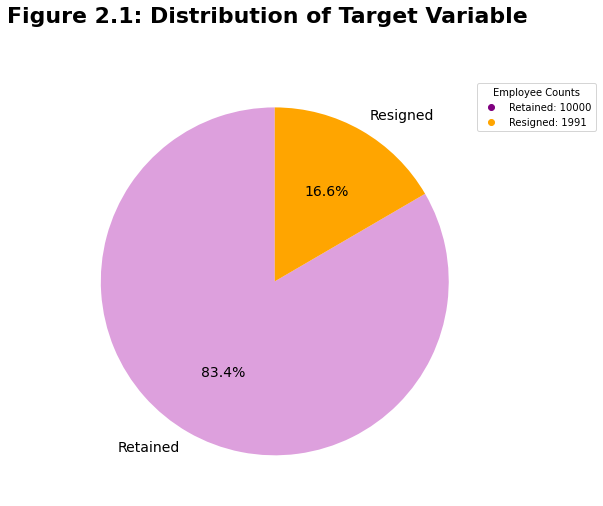

In [326]:
#plot a piechart to visualize the distribution of the target variable `left`
fig, axes = plt.subplots(figsize=(8,8))

labels = ["Retained", "Resigned"]
counts= df["left"].value_counts()
axes.pie(counts, labels=labels, autopct='%1.1f%%', colors=['plum', 'orange'], startangle=90,textprops={'fontsize': 14})

#add legend with counts
legend_labels = [f"{label}: {count}" for label, count in zip(labels, counts)]
legend_handles = [mlines.Line2D([], [], color=color, marker='o', linestyle='None') for color in ['purple', 'orange']]
plt.legend(legend_handles, legend_labels, title="Employee Counts",loc="center right", bbox_to_anchor=(1.25, 0.9))

fig.suptitle("Figure 2.1: Distribution of Target Variable",fontsize=22,fontweight='bold')
plt.show()

The dataset shows that 83.4% of employees stayed while 16.6% left. While this imbalance in the target variable must be accounted for during modeling, it is not severe enough to necessitate any class rebalancing

This helps us decide which metric is best to evaluate our model. Since the dataset is imbalanced, accuracy is not a good metric to evaluate our model. 
We will utilize the F1 score as our primary metric, as its harmonic mean effectively balances the trade-off between precision and recal


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

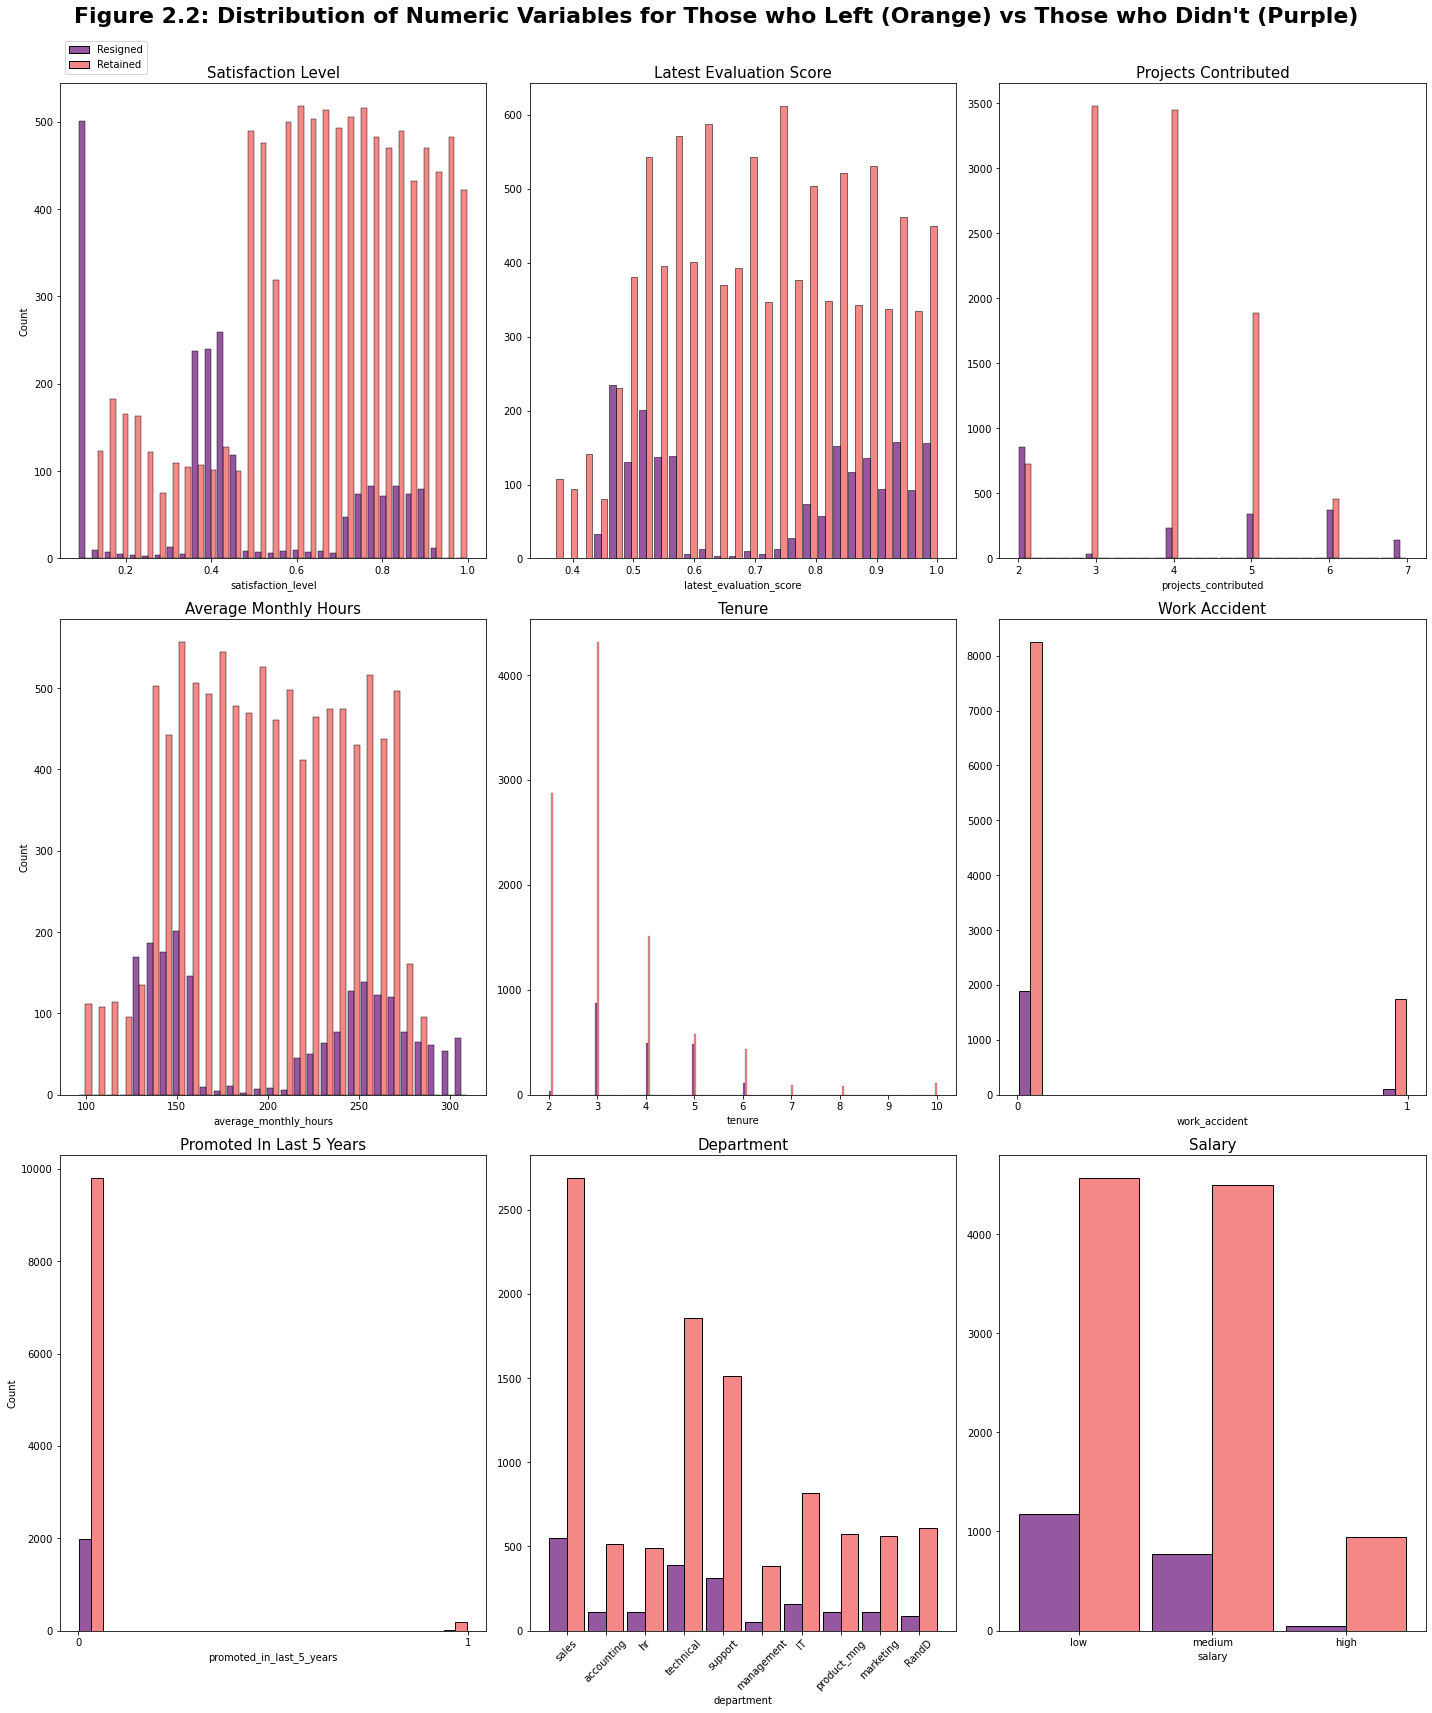

In [314]:
fig, axes = plt.subplots(3,3,figsize=(20,25))

# Flatten the 2D array to 1D for easy iteration
axes = axes.flatten()

new_labels = {0: "Retained", 1: "Resigned"}

a= 0
for i in df.columns.drop("left"):
    sns.histplot(x=df[str(i)], ax= axes[a],palette="magma", multiple='dodge',hue=df["left"].map(new_labels),legend=(a == 0), shrink=0.9)
    axes[a].set_ylabel("")
    axes[a].set_title(i.replace("_"," ").title(), fontsize=15)
    a += 1
    
for i in range(0,9,3):
    axes[i].set_ylabel("Count")

axes[5].set_xticks([0, 1])
axes[6].set_xticks([0, 1])

sns.move_legend(axes[0], "upper left", bbox_to_anchor=(0, 1.1)) # Moves it outside
axes[0].get_legend().set_title("")

for tick in axes[7].get_xticklabels():
    tick.set_rotation(45)


fig.suptitle("Figure 2.2: Distribution of Numeric Variables for Those who Left (Orange) vs Those who Didn't (Purple)", fontsize=22,fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

[ADD description]
* Satisfaction Level: Lower for those who left. we see the highest peak around 0. lower end of scale has more peaks for orange aka those who left than purple those who didnt. we see a trimodal distribution for those who left which shows that even people with higher satisfaction levels were leaving hinting towards the presence of other strong factors that resulted in people leaving
* Last Evaluation: This graph displays a bimodal distribution for employees who left the company (orange bars) compared to a more uniform/spread-out distribution for those who stayed (purple bars). Amongst those who left, there are peaks for both high performers (burnout, hunted by competitors, performance ceiling) and low performers. Performers with sweet spot average to good rating between 0.6-0.8 are least likely to leave
* Number of Projects: 2 is the peak time for those who leave. All those who worked 7 projects left
* Average Monthly Hours: Higher for those who left. Similar to last evaulation we again see a bimodal distribution. Amongst those we left we see peaks for both workers working longer as well as workers working less than the standard 160 hours (40*4) 
* Tenure: All those with 7 or more years appear to stay. In other words, all those who wanted to leave, do so before year 7. Distribution follows the same pattern for those who left vs those who didn't
* Work Accident: No apparent impact. The peak is 0 for both those who left and didn't. Amongst those who had an accident, majority didn't leave
* Promotion Last 5 years: Most didn't recieve a promotion but amongst those who did, most stayed. Despite evidence of workers working longer than the industry average it is surprising to see that so few were promoted. this could be a motiv behind lower satisfcation levels leading to attrition
* Department: There doesn't seem to be any department that differs significantly in its proportion of employees who left to those who stayed. 
* Salary: High salary indviduals are least likely to leave. Lower salary individuals are most likely to

Promotion for last 5 years variable barely has any variation

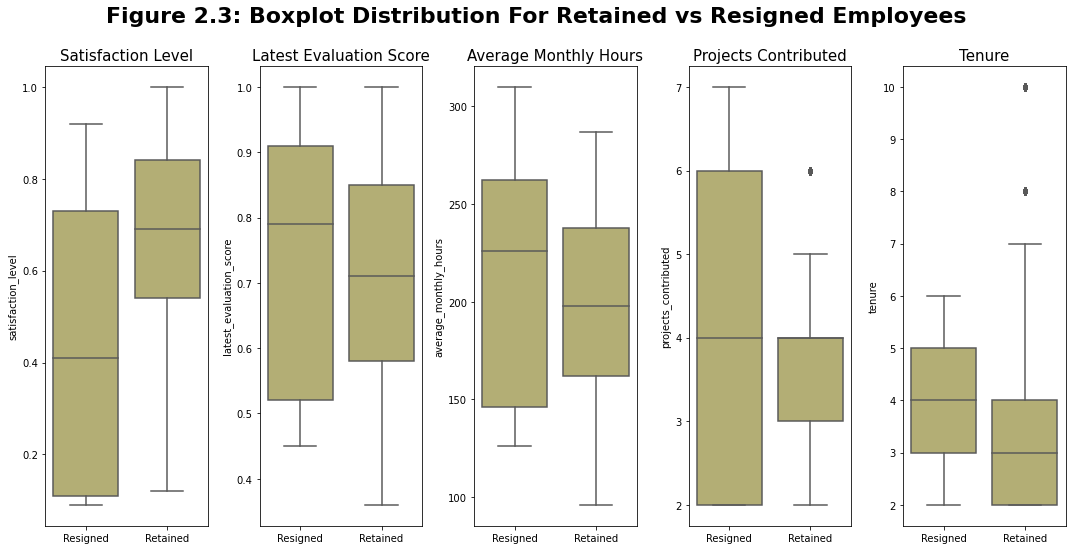

In [316]:
fig, axes = plt.subplots(1,5,figsize=(15,8))

a= 0
for i in ["satisfaction_level","latest_evaluation_score","average_monthly_hours","projects_contributed","tenure"]:
    sns.boxplot(x=df["left"].replace({0: "Retained", 1: "Resigned"}),y=df[str(i)],ax= axes[a],color='darkkhaki')
    axes[a].set_title(i.replace("_"," ").title(), fontsize=15)
    axes[a].set_xlabel("")
    a += 1
    

fig.suptitle("Figure 2.3: Boxplot Distribution For Retained vs Resigned Employees", fontsize=22,fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

* Median Satisfaction lower for those who left. IQR for those who left howevwe is varied and is in line with the bimodal distribution shown earlier. The  group (1) has a much taller box, indicating that their satisfaction levels were highly varied—some were very unhappy, while others were actually quite satisfied before leaving. Overall Spread: The "whiskers" (the lines extending from the boxes) show the full range of the data. Both groups have individuals with very low satisfaction (near 0.1), but the group that stayed has a much higher concentration of people in the upper satisfaction tiers. This visualization suggests a strong correlation between low satisfaction and employee turnover. However, because the box for those who left (1) is so wide, it also hints that "low satisfaction" isn't the only reason people leave; there is a segment of employees who left despite having relatively high satisfaction scores.

* Last evaluation, again a more varied spread for those who left but interestingly their evaluation scores tend to be higher.  those who left didn't have as many "bottom-tier" performers leaving as they did people in the mid-to-high range.The whiskers also show that the minimum of those who left is higher than the minimum of those who didnt leave. Interestingly we see that Over-Achievers are Leaving: A huge chunk of the people who left had evaluations between 0.8 and 1.0. The "Sweet Spot" for Staying: Those who stayed (0) are more tightly clustered in the 0.6 to 0.85 range.

    * Analysis of the "Last Evaluation" Graph:Higher Median and Quartiles: You are spot on. The median for those who left (1) is significantly higher (around 0.8) compared to those who stayed (0), which is around 0.7. Even the 75th percentile (the top of the box) for Group 1 is much higher, touching 0.9.

    * The "Varied Spread": The box for Group 1 is indeed much taller. This indicates that the "top performers" and "middle-tier performers" who left had very different evaluation profiles.

    * Actually, looking at the crop, the group that left (1) has a higher minimum (the bottom whisker starts higher up) than those who stayed (0). So your observation that the "lowest scores of those who left were higher" is actually accurate—they didn't have as many "bottom-tier" performers leaving as they did people in the mid-to-high range.

    * Why is this "Interesting"?In many HR datasets, we expect people to leave because they are "low performers." However, this graph shows a high-performer flight risk:

    * Over-Achievers Leaving: A huge chunk of the people who left had evaluations between 0.8 and 1.0.  (burnout, hunted by competitors, performance ceiling)

    * The "Sweet Spot" for Staying: Those who stayed (0) are more tightly clustered in the 0.6 to 0.85 range.

* When you combine this with the Average Monthly Hours graph (the middle one), you'll likely see that these high-performers were also working significantly more hours, which often points toward burnout.

* Average of Monthly hours: The median of those who left is much higher than those who didn't. Those who left have a much higher spread than those who didn't. The maximum of those who left is higher than that of those who didn't. The same is true for the minium. So we see that there are high performers, who are working more and are also leaving more frequently due to burnougt. we see a high performer flight risk. However the taller spread also shows that amongst those who left there are many who didn't work much. the 25th percentile value for those who left is lower than that of those who didn't. so we see the presence of some who weren't working much and also were leaving (low motivation, low satisfaction, work less hours)

    * the median for those who left (1) is actually higher (around 225 hours) than for those who stayed (0), who are centered just below 200 hours.

    * The box and whiskers for Group 1 are much longer.

    * The Maximum: The top whisker for Group 1 goes well over 300 hours, while Group 0 peaks around 280.

    * The Minimum: Interestingly, the bottom whisker for Group 1 is also higher (around 125 hours) than Group 0 (which starts near 100 hours).

    * The Burnout Pattern: Your conclusion about high-performer flight risk is spot on. When you cross-reference this with the "Last Evaluation" graph, a clear story emerges: The people leaving are often the ones working the most hours (250+) and receiving the highest evaluations.

    * The "Bimodal" Story
    * Looking at the "Satisfaction" and "Monthly Hours" graphs together, you can almost see two distinct types of people leaving:

    * The Overworked High-Performer: High evaluation, high hours, likely leaving due to burnout.

    * The Under-Utilized/Unhappy Worker: Low satisfaction, lower hours, perhaps leaving due to lack of engagement.

* The "Number Project" graph (the fourth one) likely reinforces this. If the group that left has a higher median number of projects, it confirms they were being "loaded up" before they reached their breaking point.

* Number Project, interestingly we see the same median. However again we see a much wider spread for those who left. those who didnt leave worked a maximum of 6, the majority only worked for upto 5 projects. those who worked the highest number of projects ie. 7 all left. this again reinforces the high performer burning out and leaving

    * The "Hard Limit" for Stayers: As you noted, for Group 0 (those who stayed), the data essentially cuts off at 6 projects. Very few people in that group are handling that kind of load.

    * The "100% Exit" Zone: Look at the top whisker for Group 1 (those who left). It hits 7 projects. Crucially, there is no corresponding data point or whisker for Group 0 at that level. This implies that once an employee is assigned a 7th project, their probability of leaving approaches 100%.

    * The "Quiet" Group: The bottom of the box for Group 1 also shows a group leaving with only 2 projects. This supports the "bimodal" theory: people leave when they are either overloaded (7 projects) or under-utilized (2 projects).
    
* those who left tend to range from 2-6 years of tenure with the median at 4. Those who didn;t leave stayed uptil 10 years but had a lower median of 3.
 
* The Survival Gate: The median tenure for those who stay is 3 years.

* The Danger Zone: For those who leave, the median is 4 years, and the bulk of the "leaving" box is concentrated between 3 and 5 years. 

* By year 6, we lose the last of our resignees

* Outliers: Interestingly, the people with the highest tenure (8 and 10 years) are shown as outliers (the little dots) in the "stayed" group. This suggests that if an employee makes it past the 6-year mark, they are statistically much more likely to stay long-term.

You’ve essentially uncovered a "High-Performer Death Spiral" in this company:

Year 3-5: Tenure reaches a critical point.

Performance: The employee is evaluated highly (0.8+).

Reward: They are rewarded with more work (7 projects and 250+ monthly hours).

Outcome: Satisfaction drops, and they leave at the peak of their value to the company.

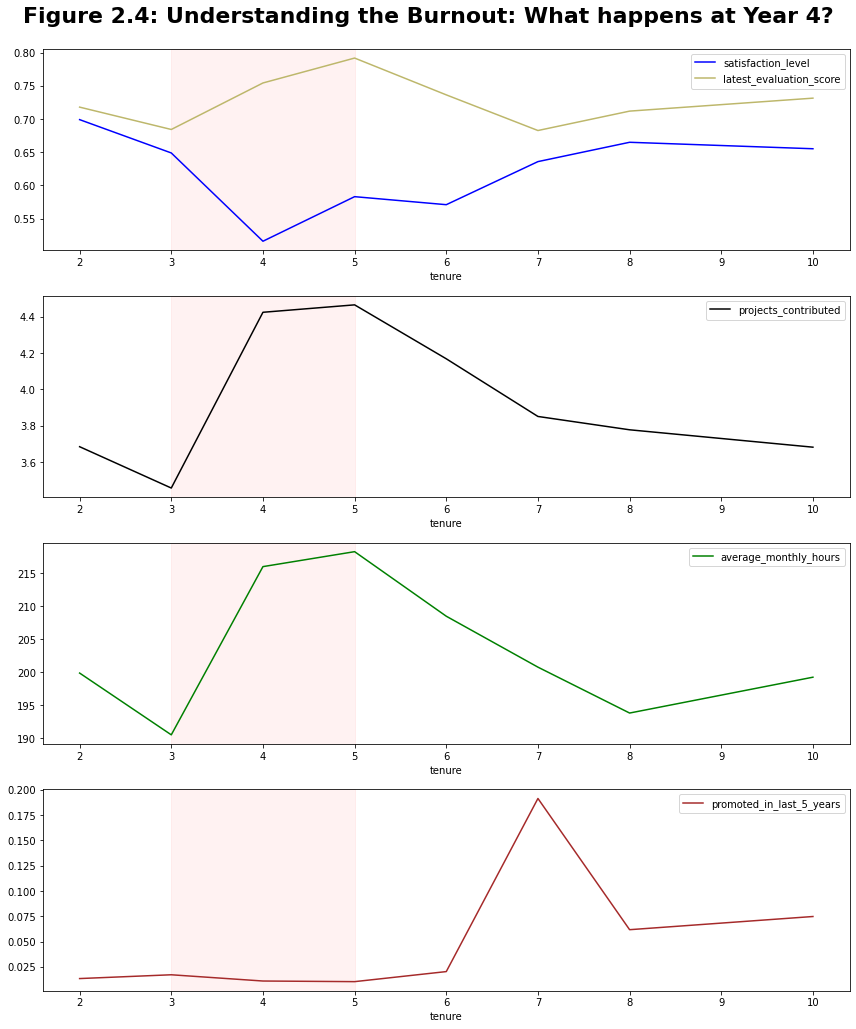

In [317]:
fig, axes = plt.subplots(4,1,figsize=(12,15))

tenure_bd= df.groupby("tenure").mean()

tenure_bd[["satisfaction_level","latest_evaluation_score"]].plot(ax=axes[0],color=['blue','darkkhaki'])
tenure_bd[["projects_contributed"]].plot(ax=axes[1], color='black')
tenure_bd[["average_monthly_hours"]].plot(ax=axes[2], color='green')
tenure_bd[["promoted_in_last_5_years"]].plot(ax=axes[3], color='brown')

for ax in axes:
    ax.axvspan(3, 5, color='red', alpha=0.05, label='Critical Retention Period')

fig.suptitle("Figure 2.4: Understanding the Burnout: What happens at Year 4?", fontsize=22,fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

As an employee moves from 3-4 tenure, satisfaction lowes, evaluation rises, numbers of projects assigned and monthly hours worked also rises.
Given that this is the move to danger zone median year,  this clearly gives evidence to the high burnout depatures

These line charts provide the "smoking gun" that confirms your burnout theory. By plotting these metrics against tenure, we can see exactly when the "High-Performer Death Spiral" hits its peak.

Here is how the data tells that story:

1. The "Crisis Zone" (Years 3 to 5)
This is the most critical part of the charts. Notice the dramatic shifts happening between year 3 and year 5:

Workload Explosion: In the middle and bottom charts, both the number of projects and average monthly hours skyrocket after year 3.

The Satisfaction Crash: Exactly as the workload peaks, satisfaction_level (blue line in the top chart) hits its absolute floor at year 4.

The Performance Peak: Interestingly, last_evaluation (orange line) continues to climb, peaking at year 5.

The Insight: Employees are being asked to do more and more because they are performing better and better. By year 4, they are doing the most work they've ever done, getting the best evaluations they've ever had, and are the most miserable they've ever been.

2. The "Great Filter" (Year 6)
Look at what happens after year 5. Every single metric—projects, hours, and evaluation—begins to drop.

Why the drop? This likely isn't because people are working less; it’s likely a survivorship bias. The high-performers who were at 7 projects and 215+ hours (the ones we saw in the boxplots) have already left the company.

Those who remain into years 7–10 are the "survivors" who perhaps have a more sustainable workload (averaging closer to 3.8 projects and 200 hours).

If you were presenting this to leadership, the narrative is clear: The company is breaking its best people. To retain top talent, the intervention needs to happen at Year 3. Management needs to decouple "high performance" from "infinite workload." If an employee hits a high evaluation at year 3, the reward should perhaps be a promotion or a raise, rather than a 7th project and 20-hour increase in monthly labor.

Does this data change how you'd view the "Number Project" boxplot from earlier? It seems 4–5 projects is the "tipping point" where satisfaction starts to tank.

The promotion is not happening until year 7. however we saw that by now all those who wanted to leave have already left

The final plot, promotion_last_5years, is the most revealing piece of the puzzle. It confirms a classic "too little, too late" management failure.

The "Stagnation" Period (Years 2–5)
Look at the purple line during the exact timeframe we identified as the Danger Zone:

While projects, hours, and evaluations are skyrocketing, the promotion rate is flat and near zero.

Employees are essentially being "rewarded" for their high performance (Evaluation > 0.75) with more work, but not with career advancement or title changes.

The "Rebound" at Year 7
There is a massive spike in promotions at Year 7. However, based on our previous analysis of the other metrics, this is highly problematic:

Survivorship Bias: The people who were most likely to be promoted (the high-performers from Year 4-5) have likely already left the company because they weren't recognized sooner.

Belated Recognition: The company only seems to promote people who have "toughed it out" for 7 years. By the time this promotion happens, satisfaction has already cratered and workload has been forced to scale back.

The Integrated Narrative: A Talent Retention Crisis
When you layer this promotion data over your previous insights, the story is stark:

The Exploitation Phase (Years 3-5): High-performers are identified. They are given 4.5+ projects and 215+ hours. Their satisfaction drops to its lowest point (0.52). Despite their "last_evaluation" peaking near 0.8, their promotion probability remains at its lowest point (near 0.01).

The Breaking Point (Year 5-6): Most of these high-performers quit. This is why we see the sharp decline in hours and projects in the following years—the heavy hitters are gone.

The Loyalty Prize (Year 7): Those who were perhaps less overworked or simply had higher personal resilience finally get promoted.

Final Business Insight
The company has a misaligned incentive structure. They are using a "time-served" promotion model (Year 7) instead of a "merit-based" one (Year 4).

To fix this, a Product Manager or Data Analyst would likely recommend:

Accelerated Promotion Tracks: Moving that Year 7 spike to Year 4 to capture high-performers before they exit.

Project Load Balancing: Capping projects at 4 or 5, as the data shows that 7 projects is a guaranteed resignation trigger.

Does this final piece of data change how you'd structure a pitch to the HR department? It seems the "promotion" lever is being pulled far too late to be an effective retention tool.

In [291]:
def scatterplt(x,y,a):
    if a == 'n/a':
        sns.scatterplot(data=df[df["left"]==0],y=y,x=x,color='purple',alpha=0.05)
        sns.scatterplot(data=df[df["left"]==1],y=y,x=x,color='orange')
        plt.suptitle("Employee Retention Patterns across "+ y.replace("_"," ").title(), fontsize=22, fontweight='bold')
    else:
        sns.scatterplot(data=df[df["left"]==0],y=y,x=x,color='purple',alpha=0.05, ax=axes[a])
        sns.scatterplot(data=df[df["left"]==1],y=y,x=x,color='orange', ax=axes[a])
        axes[a].set_title("Variation with "+x.replace("_"," ").title(),fontsize=15)
        
    # 1. Create custom "handles" for the legend
    orange_dot = mlines.Line2D([], [], color='orange', marker='o', linestyle='None', label='Resigned')
    purple_dot = mlines.Line2D([], [], color='purple', marker='o', linestyle='None', label='Retained', alpha=0.3)

    # 2. Add a single legend to the figure (not the axis)
    fig.legend(handles=[orange_dot, purple_dot], 
           loc='lower center', 
           ncol=2, 
           frameon=False,
            bbox_to_anchor=(0.5, -0.01),
           fontsize=12)

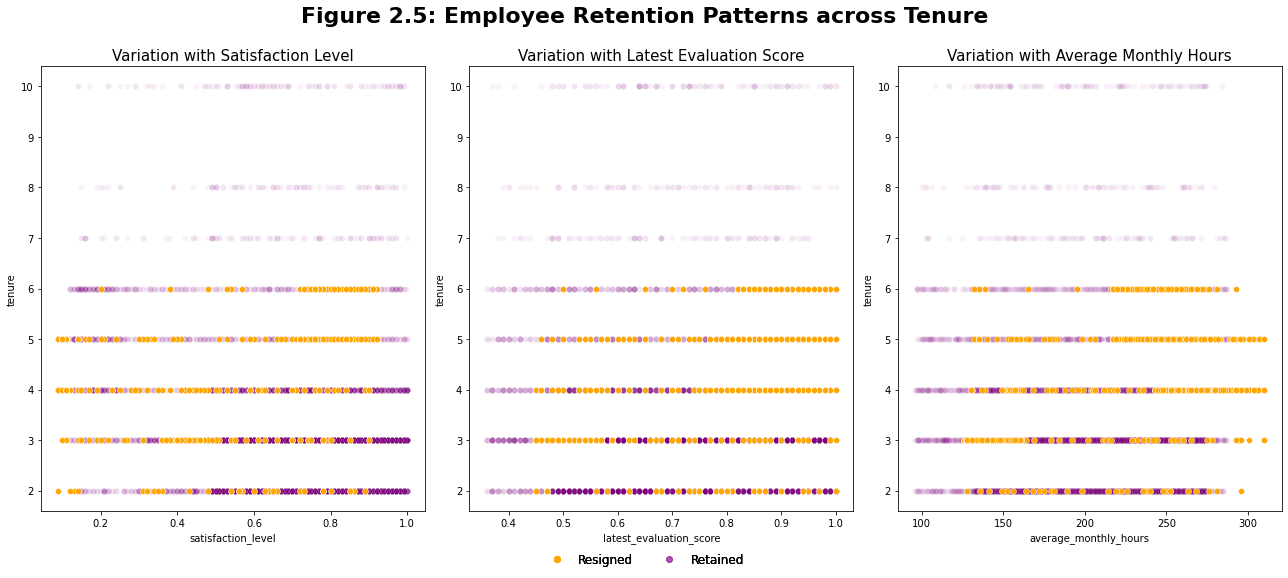

In [318]:
fig, axes = plt.subplots(1,3,figsize=(18,8))

axes = axes.flatten()

scatterplt("satisfaction_level","tenure",0)
scatterplt("latest_evaluation_score","tenure",1)
scatterplt("average_monthly_hours","tenure",2)
fig.suptitle("Figure 2.5: Employee Retention Patterns across Tenure",fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])


One final observation on your plot: Notice how the orange dots (Resignees) are almost entirely missing from the 7, 8, 9, and 10-year tenure rows. This is a huge insight! It suggests that once an employee hits year 7 at Salifort Motors, they are very unlikely to leave, regardless of their satisfaction or hours. You might want to mention this "Loyalty Threshold" in your final analysis.

This visualization displays three scatter plots analyzing how employee tenure relates to satisfaction, performance evaluations, and workload, specifically distinguishing between those who left the company (Resignees in orange) and those who stayed (Non-Resignees in purple).

The most striking takeaway is that turnover is highly concentrated between years 3 and 6. Employees with very low tenure (2 years) or high tenure (7–10 years) appear significantly more stable.

Key Insights by Metric
1. Figure 1: Satisfaction Level vs. Tenure

The "Burnout" Group: There is a dense cluster of resignees at year 4-6 with very high satisfaction. These might be high-performers leaving for better opportunities.

The "Unhappy" Group: A distinct cluster of resignees appears at year 3-4 with very low satisfaction (below 0.2). This suggests a "breaking point" where dissatisfied employees exit after a few years.

Retention Zone: Employees who stay (purple) are spread across all satisfaction levels, but they dominate the 7+ year tenure marks regardless of their happiness.

2. Figure 2: Last Evaluation vs. Tenure

The High-Performer Flight: A significant number of resignations occur among employees with evaluation scores above 0.8, particularly between years 4 and 6. This is a "talent drain" scenario.

The Underperformer Exit: There is another cluster of resignees with low evaluation scores (around 0.4–0.5) at the 3-year mark, which could indicate performance-related turnover or mutual parting.

3. Figure 3: Average Monthly Hours vs. Tenure

Overworked Leavers: There is a clear horizontal band of orange dots at years 4, 5, and 6 for employees working over 250 hours per month. Extreme workload seems to be a primary driver for mid-tenure resignations.

Underutilized Leavers: Interestingly, there is also a cluster of resignees at year 3 who work relatively few hours (around 120–150). These individuals may feel under-challenged or disconnected.

Summary of Patterns
The "Danger Zone" for this organization is the 3 to 6-year tenure window.

At 3 years: Turnover is driven by low satisfaction and low workload (potential lack of engagement).

At 4-6 years: Turnover is driven by high performance and high workload (potential burnout or being headhunted).

Stability: If an employee reaches year 7, the likelihood of resignation drops off precipitously, suggesting that those who stay past year 6 are likely "lifers" or highly integrated into the culture.

Would you like to focus the analysis on a specific group, such as the high-performers who are leaving?

In [319]:
# Lets create a seperate variable for those in the critical retention period of 3-5 years to compare with those outside of that period.
df['mid_tenure'] = np.where((df['tenure'] >= 3) & (df['tenure'] <= 5),1,0)

## Let's see how satisfaction levels vary with those in groups 3-5

# H0: no difference
# H2: difference

# 1. Isolate the `satisfaction_level` column for mid-tenure employees.

mid_tenure = df[(df['mid_tenure'] == 1)]['satisfaction_level']

# 2. Isolate the `satisfaction_level` column for employees outside the mid-tenure period.
not_mid_tenure = df[(df['mid_tenure'] == 0)]['satisfaction_level']

# 3. Perform a Welch's t-test

two_sample= stats.ttest_ind(a=mid_tenure, b=not_mid_tenure, equal_var=False)
print(f"Results of Two-sample t-test\n \nT-stat: {two_sample[0]} \nP-value: {two_sample[1]}")
    

Results of Two-sample t-test
 
T-stat: -15.631955199332078 
P-value: 2.4736359776349493e-54


Analyzing Mid-Tenure Employee Satisfaction

A Welch's t-test confirmed that mid-tenure employees (3-5 years) have significantly lower satisfaction levels compared to all other tenure groups ($t = -15.63, p < 0.001$). This result is statistically robust and represents a critical "danger zone" for employee retention.

**Key Interpretation:**
- The extremely low p-value (p < 0.001) indicates this difference is not due to random chance
- Mid-tenure employees are substantially less satisfied than their peers at other career stages
- This "mid-career dip" in satisfaction aligns with the burnout pattern observed in previous visualizations, where years 3-5 show peak workload, high performance evaluations, but minimal career advancement (promotions)



Next we see how resignation rates vary with those in groups 3-5

Mid-Tenure Employee Resignation Analysis
Mid-Tenure Resignees (3-5 years): 1851 out of 8257 (22.4% of all employees)
Other Resignees: 140 out of 3734 (3.7% of all employees)

Mid-tenure employees represent 93.0% of all resignees


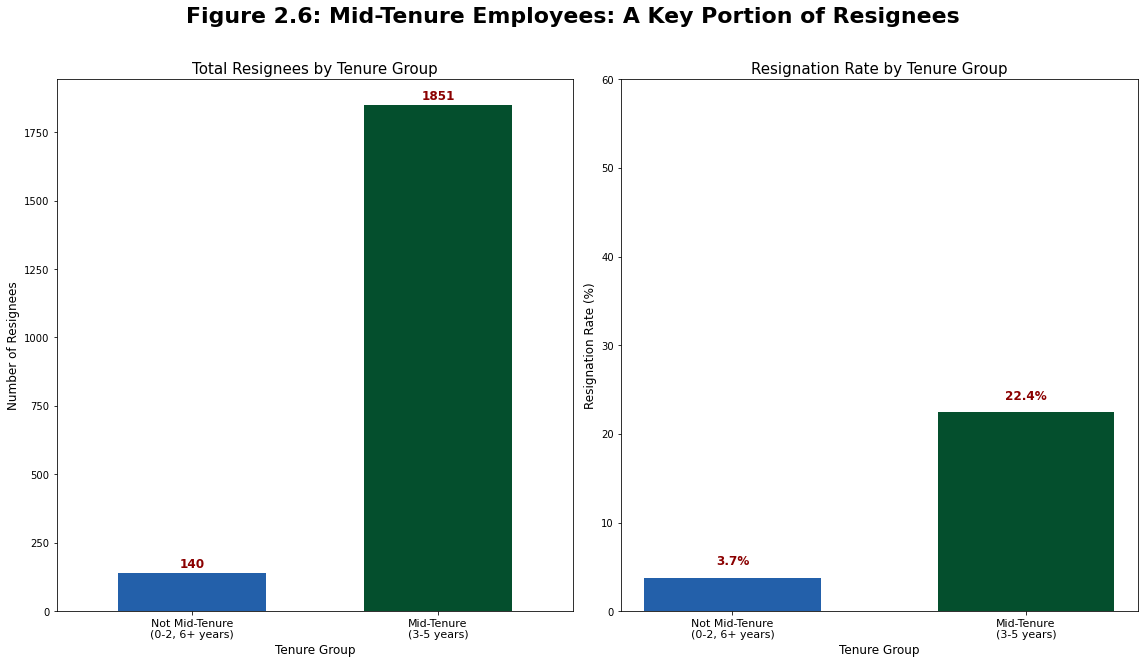

In [330]:
# Calculate resignation rates by mid-tenure status
mid_tenure_analysis = df.groupby('mid_tenure')['left'].agg(['sum', 'count'])
mid_tenure_analysis['resignation_rate'] = mid_tenure_analysis['sum'] / mid_tenure_analysis['count']
mid_tenure_analysis.index = ['Not Mid-Tenure (0-2, 6+ years)', 'Mid-Tenure (3-5 years)']

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Plot 1: Resignation counts
colors = ["#2360AA", "#044F2D"]
mid_tenure_analysis['sum'].plot(kind='bar', ax=axes[0], color=colors, width=0.6)
axes[0].set_title('Total Resignees by Tenure Group', fontsize=15)
axes[0].set_ylabel('Number of Resignees', fontsize=12)
axes[0].set_xlabel('Tenure Group', fontsize=12)
axes[0].set_xticklabels(['Not Mid-Tenure\n(0-2, 6+ years)', 'Mid-Tenure\n(3-5 years)'], fontsize=11, rotation=360,ha='center')
for i, v in enumerate(mid_tenure_analysis['sum']):
    axes[0].text(i, v + 20, str(int(v)), ha='center', fontsize=12, fontweight='bold', color='darkred')

# Plot 2: Resignation rate (%)
resignation_pct = (mid_tenure_analysis['resignation_rate'] * 100)
bars = axes[1].bar(range(len(resignation_pct)), resignation_pct, color=colors, width=0.6)
axes[1].set_title('Resignation Rate by Tenure Group', fontsize=15)
axes[1].set_ylabel('Resignation Rate (%)', fontsize=12)
axes[1].set_xlabel('Tenure Group', fontsize=12)
axes[1].set_xticks(range(len(resignation_pct)))
axes[1].set_xticklabels(['Not Mid-Tenure\n(0-2, 6+ years)', 'Mid-Tenure\n(3-5 years)'], fontsize=11)
axes[1].set_ylim(0, 60)
for i, (bar, v) in enumerate(zip(bars, resignation_pct)):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12, color='darkred')

fig.suptitle('Figure 2.6: Mid-Tenure Employees: A Key Portion of Resignees', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics
print("Mid-Tenure Employee Resignation Analysis")
print("=" * 60)
print(f"Mid-Tenure Resignees (3-5 years): {int(mid_tenure_analysis.loc['Mid-Tenure (3-5 years)', 'sum'])} out of {int(mid_tenure_analysis.loc['Mid-Tenure (3-5 years)', 'count'])} ({resignation_pct.iloc[1]:.1f}% of all employees)")
print(f"Other Resignees: {int(mid_tenure_analysis.loc['Not Mid-Tenure (0-2, 6+ years)', 'sum'])} out of {int(mid_tenure_analysis.loc['Not Mid-Tenure (0-2, 6+ years)', 'count'])} ({resignation_pct.iloc[0]:.1f}% of all employees)")
print(f"\nMid-tenure employees represent {(mid_tenure_analysis.loc['Mid-Tenure (3-5 years)', 'sum'] / mid_tenure_analysis['sum'].sum() * 100):.1f}% of all resignees")

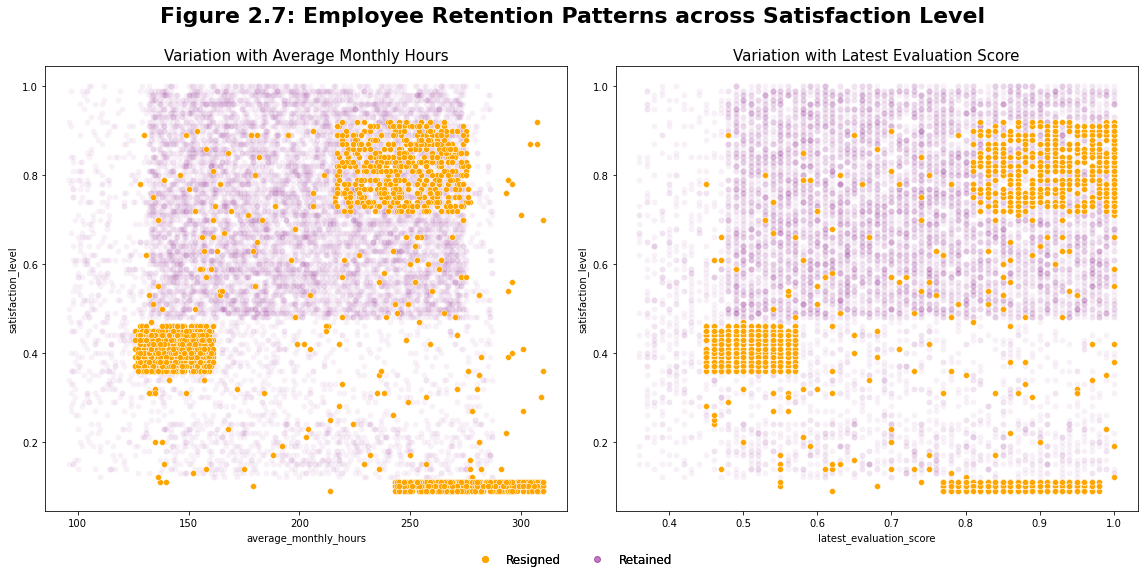

In [321]:
fig, axes = plt.subplots(1,2,figsize=(16,8))
axes = axes.flatten()

scatterplt("average_monthly_hours","satisfaction_level",0)
scatterplt("latest_evaluation_score","satisfaction_level",1)
fig.suptitle("Figure 2.7: Employee Retention Patterns across Satisfaction Level",fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

The left two visualizations reveal three distinct clusters of employees who left the organization:

1. The "Workhorses" (Top Right)Profile: High Satisfaction ($> 0.7$), High Evaluation ($> 0.8$), and High Monthly Hours ($220$–$275+$).Interpretation: These are your top performers. They are satisfied and highly rated but are likely being overworked. They may be leaving for better opportunities or because they have hit a ceiling, despite being "happy."

2. The "Strugglers" (Middle)Profile: Moderate Satisfaction ($0.35$–$0.45$), Low/Mid Evaluation ($\approx 0.45$–$0.55$), and Lower Hours ($\approx 130$–$160$).Interpretation: These employees seem to be in a "danger zone." They aren't performing well, aren't very satisfied, and aren't working many hours. This cluster likely represents people who were either a bad fit for their roles or were already mentally checked out before leaving.

3. The "Burnt Out" (Top Left)Profile: Very Low Satisfaction ($< 0.2$), High Evaluation ($> 0.8$), and Very High Hours ($250$–$300+$).Interpretation: This is a classic burnout profile. These are high-performing individuals (per the last_evaluation plot) who are working extreme hours but are miserable. Their low satisfaction is a direct indicator of impending resignation due to overwork.

Key Takeaway

The data suggests that turnover isn't just about "unhappy" people. You have a significant retention issue with high achievers.The High-Hour/High-Evaluation group (Top Right and Top Left) represents the most "expensive" loss to the company.

The Satisfaction/Evaluation gap: Notice how in the bottom plot, the orange clusters are very tightly packed at high evaluation levels, suggesting that the company is specifically losing its most competent talent.

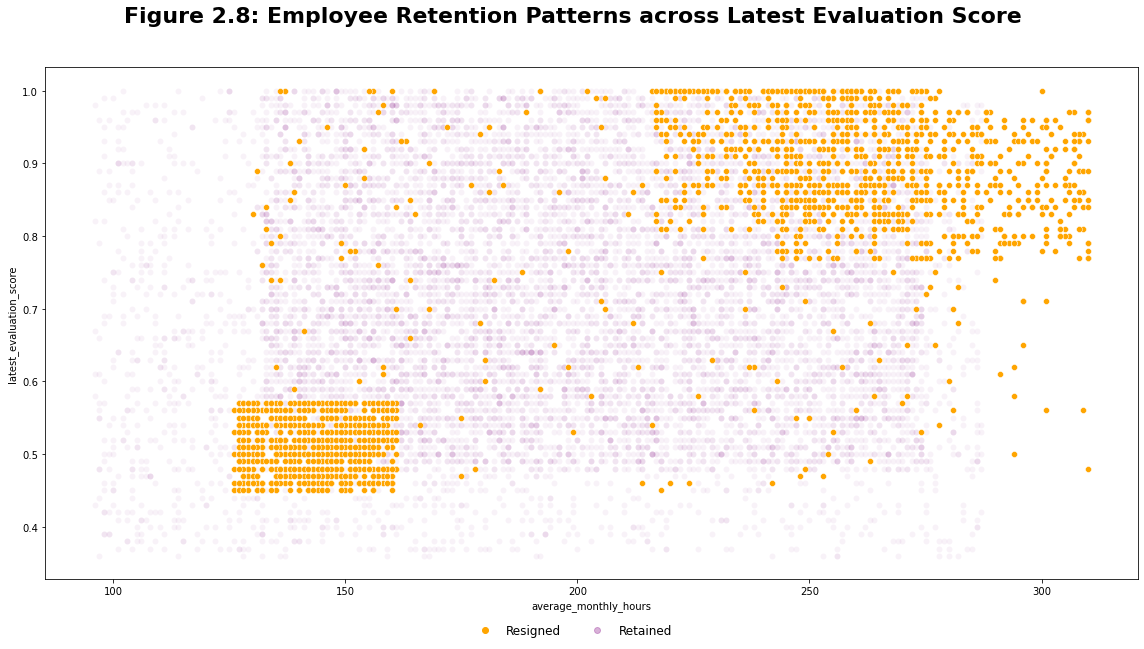

In [268]:
fig, axes = plt.subplots(figsize=(16,9))

scatterplt("average_monthly_hours","latest_evaluation_score",'n/a')
fig.suptitle("Figure 2.8: Employee Retention Patterns across Latest Evaluation Score",fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## Insights

[What insights can you gather from the plots you created to visualize the data? Double-click to enter your responses here.]

[TO ADD]

## Section 3: Model Building and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



**Identify the type of prediction task.**

This is a supervised learning classification task because we will predict on a binary class (Whether or not each employee left or stayed). Therefore, this notebook will prepare the data for a classification model.

**Identify the types of models most appropriate for this task.**

I will build both a Logistic Regression and two Machine Learning Models (Random Forest + XGBoosting)

**Data Prep**

In [185]:

df_model = df.copy()
# Encode the `salary` column as an ordinal numeric category
df_model['salary'] = df['salary'].astype('category').cat.set_categories(['low', 'medium', 'high']).cat.codes
# Dummy encode the `department` column
df_model = pd.get_dummies(df_model, drop_first=False)
# as we have created a new variable for the critical retention period of 3-5 years, we can drop the original tenure variable to avoid multicollinearity
df_model.drop(columns="tenure", inplace=True) 

Employee turnover (Left) exhibits a negative correlation with satisfaction_level, while maintaining weak positive correlations with last_evaluation, number_project, average_monthly_hours, and tenure. These muted coefficients likely stem from the non-linear nature of the data; specifically, the 'high-performer burnout' effect is likely being masked by the exit of dissatisfied low-performers. This divergence in exit profiles suggests that a standard linear regression model may fail to capture the underlying complexities of employee attrition."


### Logistic Regression

#### Logistic Regression model assumptions 

**Pre Construction**

* Outcome variable is categorical? Yes as the left variable is binary
* Observations are independent of each other? Yes as each observation refers to an independent employee
* No severe multicollinearity among X variables? See results from heatmap
* No extreme outliers? Yes as we no longer have tenure
* Sufficiently large sample size? Yes as n ~ 15,000

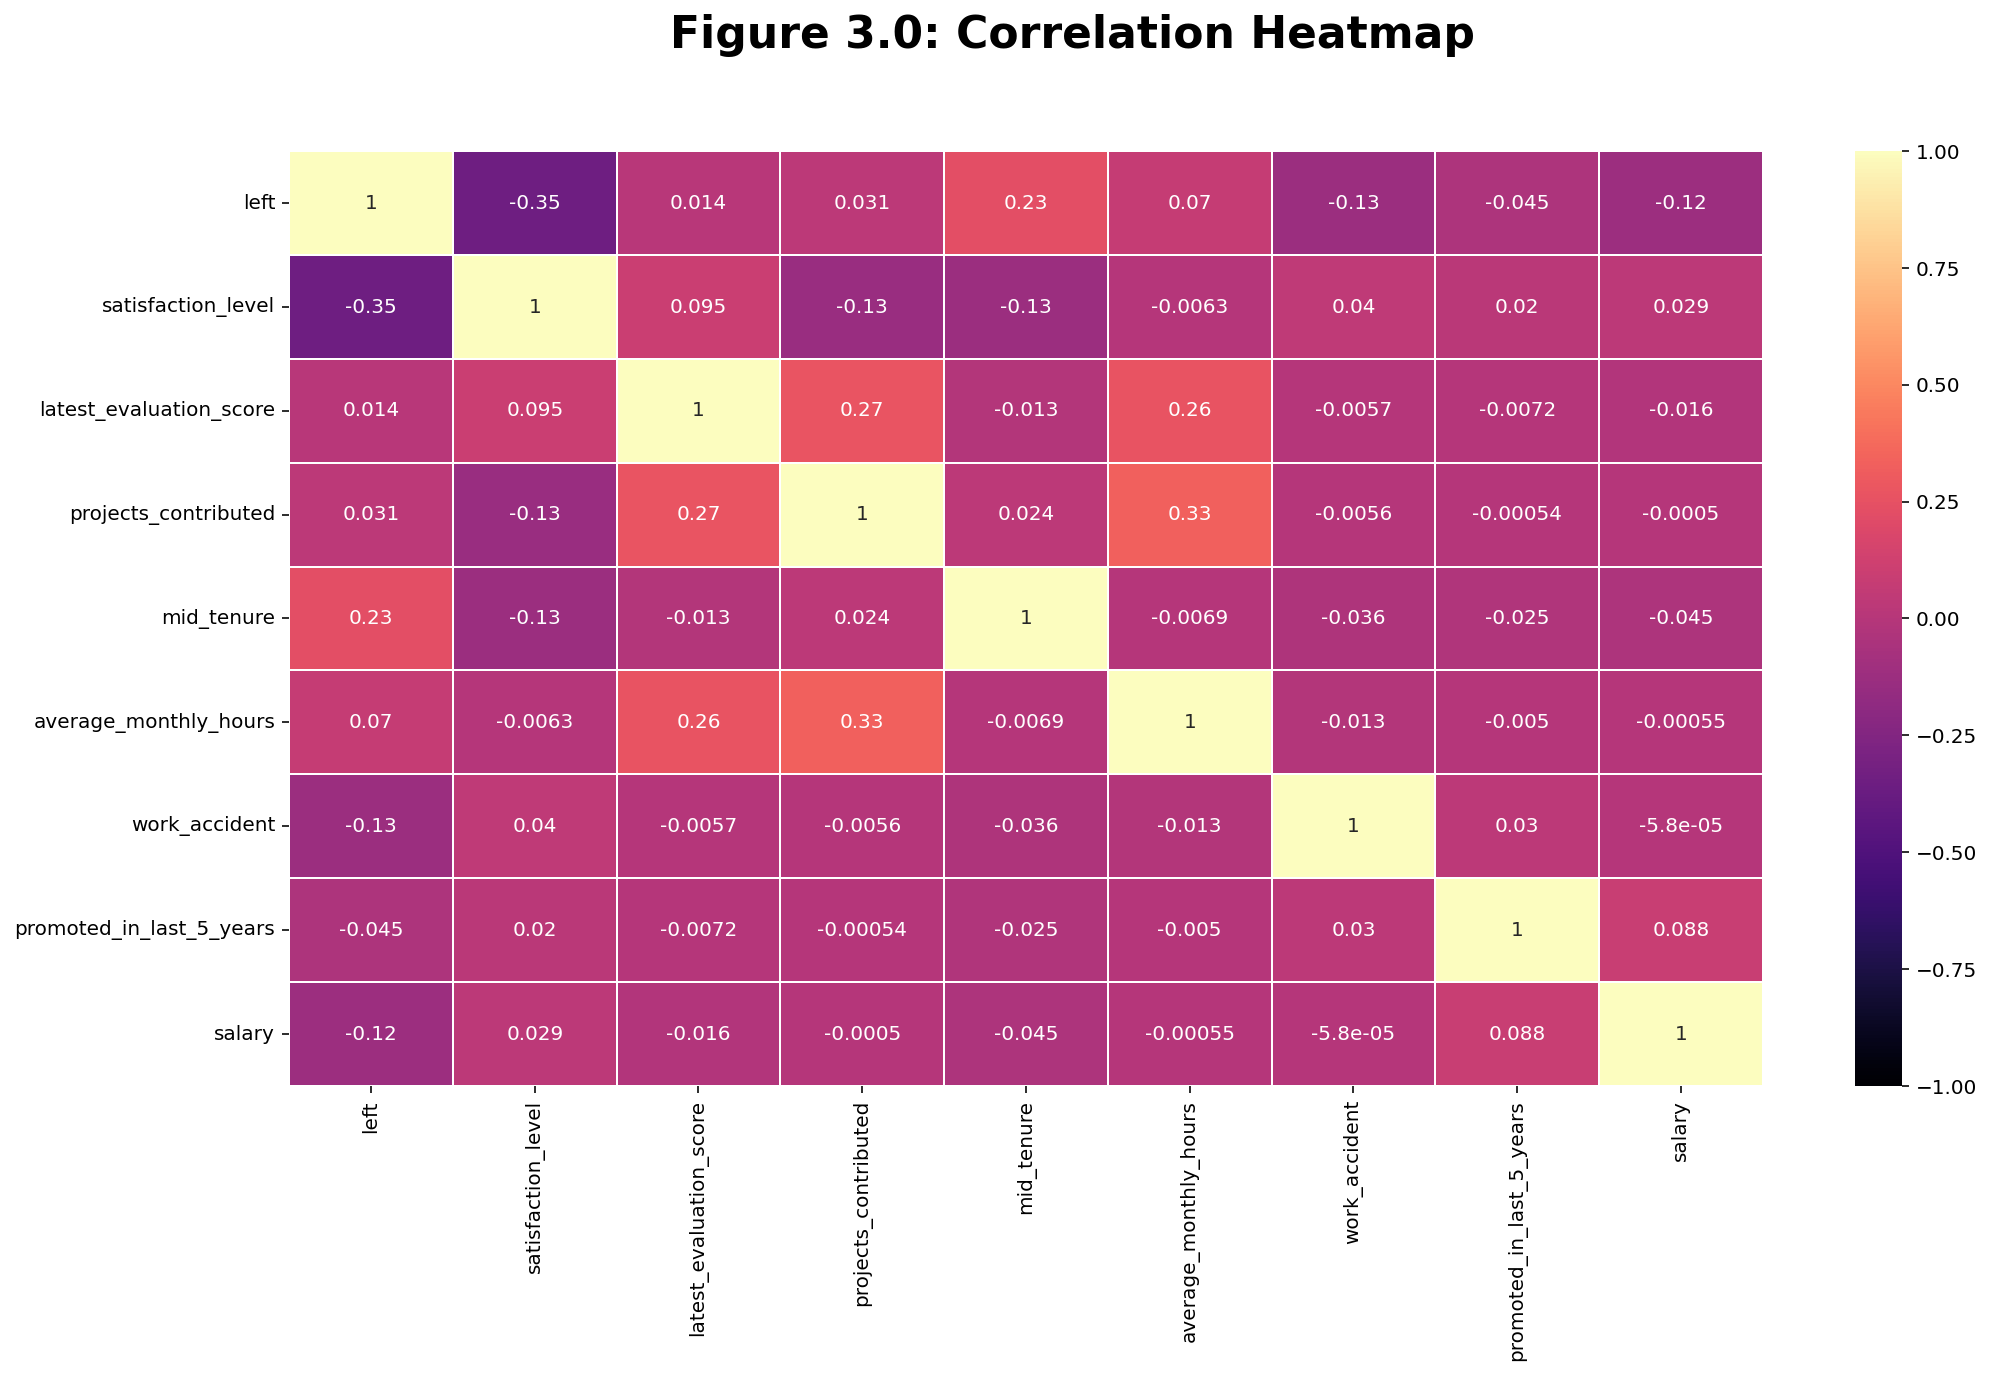

In [186]:
#### Check correlation amongst predictors

fig, axes = plt.subplots(figsize=(15,10))

sns.heatmap(df_model[['left','satisfaction_level', 'latest_evaluation_score', 'projects_contributed', 'mid_tenure', 'average_monthly_hours',
                    'work_accident', 'promoted_in_last_5_years','salary']].corr(), vmin=-1, vmax=1,
            annot=True,cmap = 'magma',linecolor='white', linewidth=0.1)
fig.suptitle('Figure 3.0: Correlation Heatmap',fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show();

In [187]:
# Save X and y data into variables
X_log = df_model.drop(columns='left')
y_log = df_model["left"]

#stratify = y as classes are imbalanced
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, stratify=y_log, test_size=0.25, random_state=42)

# Build regression model

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_log,y_train_log)

LogisticRegression(max_iter=1000)

 **(Post Construction)**

* Linear relationship between each X variable and the logit of the outcome variable? See results from regression plots below. Some violations but mostly yes

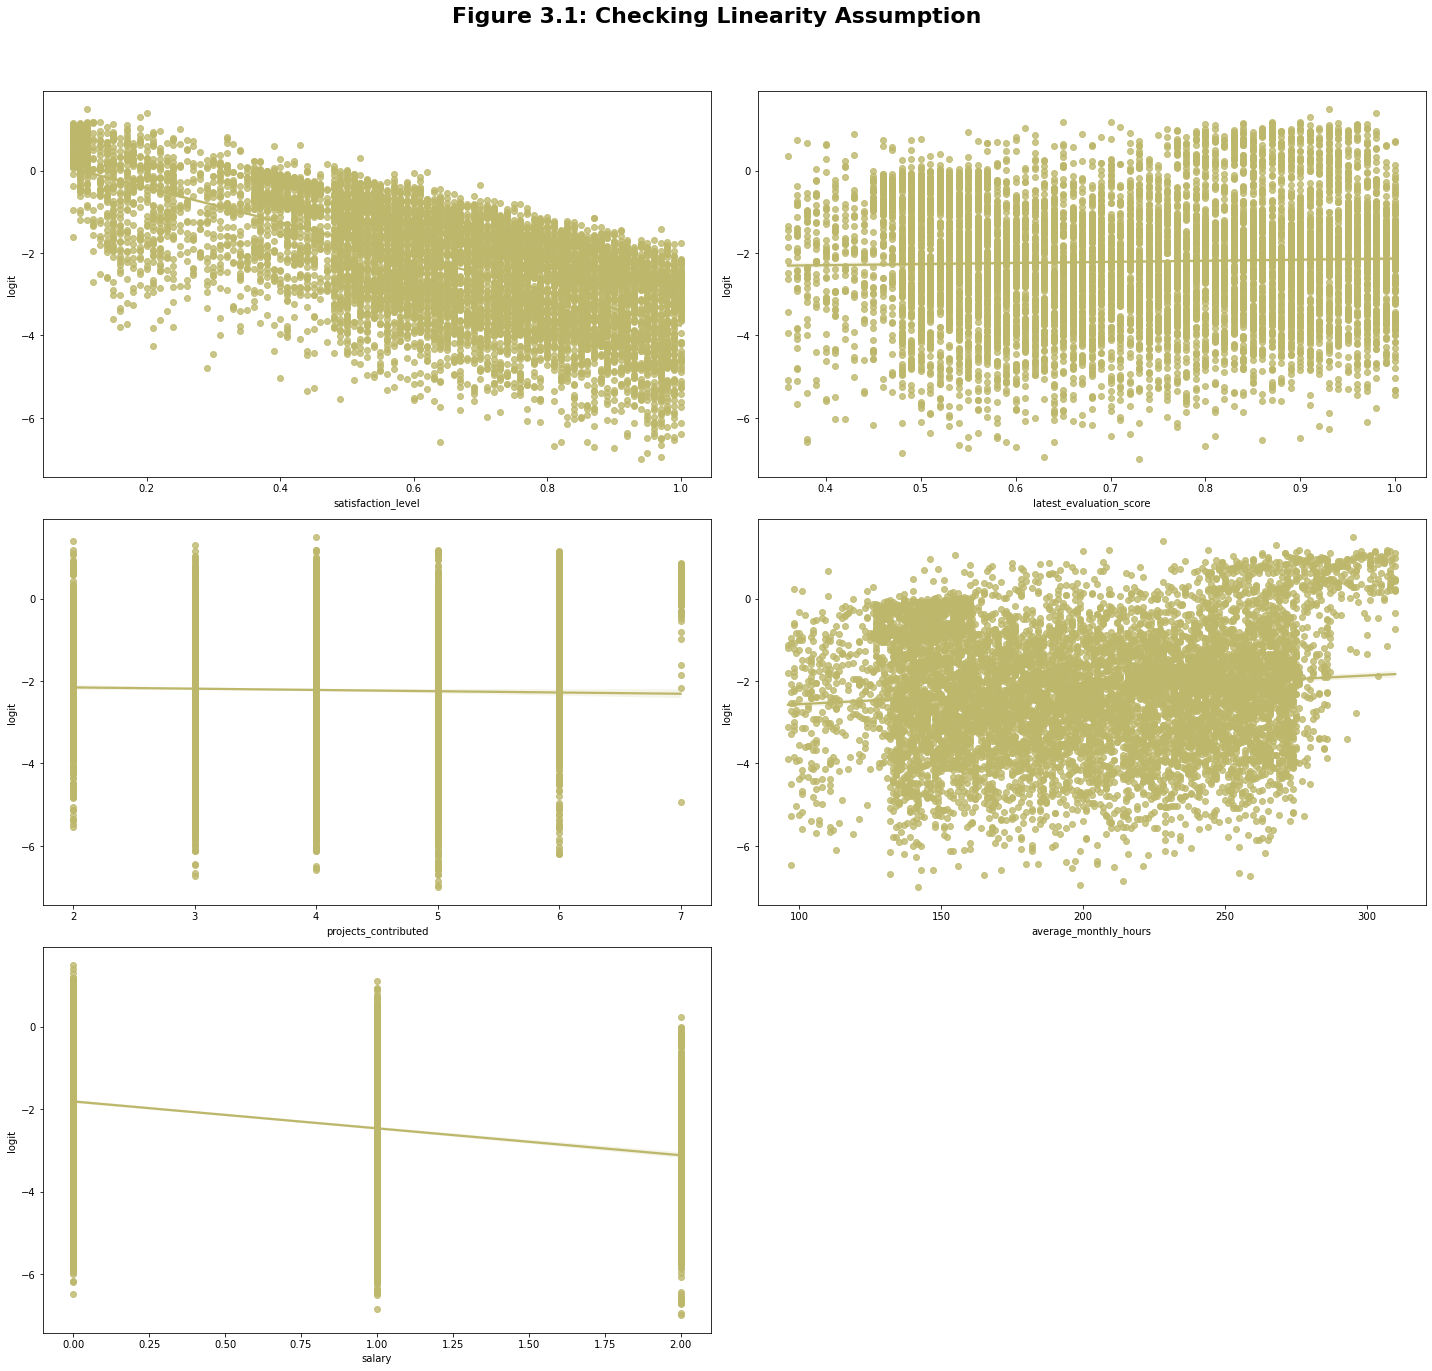

In [188]:

## Checking Linearity assumption

training_probabilities = clf.predict_proba(X_train_log)
training_probabilities

# 1. Copy the `X_train` dataframe and assign to `logit_data`
logit_data = X_train_log

# 2. Create a new `logit` column in the `logit_data` df

logit_data["logit"] = [np.log(prob[1]/prob[0]) for prob in training_probabilities]

# 3. Plot the logit values against each predictor to check for linearity assumption
fig, axes = plt.subplots(3,2,figsize=(20,20))

# Flatten the 2D array to 1D for easy iteration
axes = axes.flatten()

# Only including numeric and discrete predictors to check for linearity assumption
a= 0
for i in ["satisfaction_level", "latest_evaluation_score",'projects_contributed', "average_monthly_hours", 'salary']:
    sns.regplot(x = str(i), y = "logit", data = logit_data, ax=axes[a], color='darkkhaki')
    a += 1

axes[5].set_visible(False)
fig.suptitle('Figure 3.1: Checking Linearity Assumption',fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show();

In [189]:
# Check model coefficients to understand directionality of relationships
coef_df = pd.DataFrame({
    'Feature': X_train_log.columns.drop("logit"),
    'Coefficient': clf.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
coef_df.reset_index(drop=True).head(5)

,Feature,Coefficient
0,satisfaction_level,-3.833440
1,mid_tenure,1.729223
2,work_accident,-1.317757
3,latest_evaluation_score,0.929513
4,salary,-0.538790


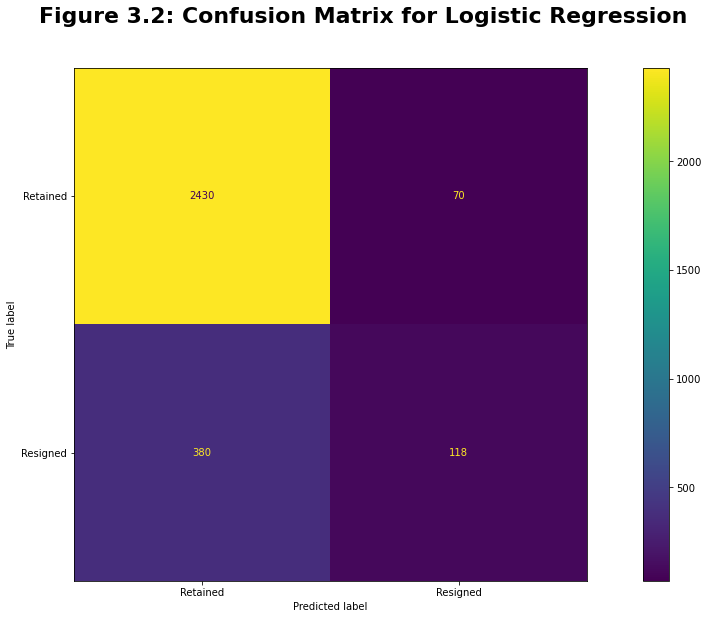

In [190]:
# Use the logistic regression model to get predictions on the test set
y_pred_log = clf.predict(X_test_log)

# Compute values and display  confusion matrix
cm = confusion_matrix(y_test_log, y_pred_log, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = ["Retained","Resigned"])

fig, ax = plt.subplots(figsize=(16, 9))
disp.plot(ax=ax)
fig.suptitle("Figure 3.2: Confusion Matrix for Logistic Regression", fontsize=22, fontweight='bold', x=0.6, horizontalalignment='center')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The model predicts very few True Positives, hinting a low recall and precision score. It accurately predicts many True Negatives so accuracy is likely to be high. However, for our purposes a high accuracy isn't enough as we are most interested in identifying True Positives and minimizing False Negatives

Notice from this confusion matrix that the model correctly predicts many true negatives. 
Of course, this is to be expected, given that the dataset is imbalanced in favor of negatives


In [191]:
# Get accuracy scores
log_precision = precision_score(y_test_log,y_pred_log)
log_accuracy = accuracy_score(y_test_log,y_pred_log)
log_recall = recall_score(y_test_log,y_pred_log)
log_f1 = f1_score(y_test_log,y_pred_log)

In [192]:
results = pd.DataFrame()
results = pd.DataFrame({'model': 'Logistic_Regression',
                          'precision': log_precision,
                          'recall':log_recall,
                          'F1': log_f1,
                          'accuracy': log_accuracy}, index=range(0,1))
results

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.62766,0.236948,0.344023,0.8499


High Accuracy but very low recall and f1 score with a moderate precision. This makes it crucial to choose another model. accuracy not good metric due to class imbalance

### Machine Learning Models (Random Forest and XGBoost)

1. Split data into test, validate, train
2. Train Random Forest and XGboost on training data
3. Run the best RF and XGboost models on validation data
4. Choose the champion model with the highest score 
5. Run Champion Model on test data

#### Split data into test train and validation sets

Lets drop satisfaction level as it doesn't provide anything meaningful. It is obvious that employees who are less satisfied are likely to leave, lets see what other predictors capture

gemini:

removing it can help you uncover the more actionable, structural drivers of attrition.

Here is a breakdown of why this is a solid analytical move and what you should look for next.

1. The Rationale: Actionability vs. Accuracy
While satisfaction is a great predictor, it is often a lagging indicator. By the time an employee reports low satisfaction on a survey, they may have already mentally checked out. From a Product Management or HR-strategy perspective, knowing that "unhappy people leave" isn't as helpful as knowing why they are unhappy.

By removing it, you force the Random Forest to find the root causes—such as salary imbalances, excessive overtime, or lack of promotion—rather than just the symptom (low satisfaction).

In [193]:
#X = df_model.drop(columns='left')
X = df_model.drop(columns=['left','satisfaction_level'])
y = df_model["left"]

# Split into train and test sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, stratify=y,
                                              test_size=0.2, random_state=42)

# Split into train and validate sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, stratify=y_tr,
                                                  test_size=0.25, random_state=42)

#### Train Random Forest Model

In [194]:
%%time

rf = RandomForestClassifier(random_state=42)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 0.9],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

# Assign a dictionary of scoring metrics to capture
scoring = {'accuracy', 'precision', 'recall', 'f1', 'recall'}

# Instantiate GridSearch
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='f1')

#rf_cv.fit(X_train, y_train) 

CPU times: user 184 µs, sys: 109 µs, total: 293 µs
Wall time: 62.2 µs


In [195]:
# Define a path to the folder where you want to save the model
path = Path.home() / "Downloads" / "Coursera" / "Google Advanced Data Analytics" / "Project_Salisfort_Motors_Employee_Attrition" / "hr_rf_cv_model.pickle"

In [196]:
#with open(path, 'wb') as to_write:
#   pickle.dump(rf_cv, to_write)

In [197]:
with open(path, 'rb') as to_read:
   rf_cv = pickle.load(to_read)

In [198]:
rf_cv.best_score_

0.8349338249508876

In [199]:
rf_cv.best_params_

{'max_depth': None,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

Use the make_results() function to output all of the scores of your model. Note that the function accepts three arguments

In [200]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )

    return table

In [201]:
results_rf_cv = make_results('Random Forest CV', rf_cv, 'f1')

results = pd.concat([results, results_rf_cv], axis=0)
results.reset_index(drop=True)

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.627660,0.236948,0.344023,0.849900
1,Random Forest CV,0.879418,0.794979,0.834934,0.947733


All of metrics massively improved

#### Train XGBoost Model

In [202]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [3,4,5],
             'min_child_weight': [1,2,3],
             'learning_rate': [0.1],
             'n_estimators': [300]
             }

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')

In [203]:
%%time
xgb_cv.fit(X_train, y_train)

CPU times: user 44.4 s, sys: 11.1 s, total: 55.4 s
Wall time: 8.11 s


GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None

In [204]:
# Examine best score
xgb_cv.best_score_

0.8245396649226756

In [205]:
# Examine best parameters
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 300}

In [206]:
results_xgb_cv = make_results('XGBoost CV', xgb_cv, 'f1')
results = pd.concat([results, results_xgb_cv], axis=0)
results.reset_index(drop=True)

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.627660,0.236948,0.344023,0.849900
1,Random Forest CV,0.879418,0.794979,0.834934,0.947733
2,XGBoost CV,0.864334,0.788282,0.824540,0.944259


#### Run the best Random Forest on Validation Data

Use the get_test_scores() function to generate a table of scores from the predictions on the validation data.

In [207]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

In [208]:
# Use random forest model to predict on validation data
rf_val_preds = rf_cv.best_estimator_.predict(X_val)

# Get validation scores for RF model
rf_val_scores = get_test_scores('Random Forest Validation', rf_val_preds, y_val)

# Append to the results table
results = pd.concat([results, rf_val_scores], axis=0)
results.reset_index(drop=True)

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.627660,0.236948,0.344023,0.849900
1,Random Forest CV,0.879418,0.794979,0.834934,0.947733
2,XGBoost CV,0.864334,0.788282,0.824540,0.944259
3,Random Forest Validation,0.850949,0.788945,0.818774,0.942035


#### Run the best XGBoost Model on Validation Data

In [209]:
# Use XGBoost model to predict on validation data
xgb_val_preds = xgb_cv.best_estimator_.predict(X_val)

# Get validation scores for XGBoost model
xgb_val_scores = get_test_scores('XGBoost Validation', xgb_val_preds, y_val)

# Append to the results table
results = pd.concat([results, xgb_val_scores], axis=0)


results.reset_index(drop=True)

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.627660,0.236948,0.344023,0.849900
1,Random Forest CV,0.879418,0.794979,0.834934,0.947733
2,XGBoost CV,0.864334,0.788282,0.824540,0.944259
3,Random Forest Validation,0.850949,0.788945,0.818774,0.942035
4,XGBoost Validation,0.859890,0.786432,0.821522,0.943286


#### Choose Champion Model

The best model as run on the Validation data as shown above is the XGBoost model

#### Run Champion Model on Test Data

In [210]:
#Retrain the XGB model on  Training + Validation data i.e. full data

champion = xgb_cv.best_estimator_
champion.fit(X_tr, y_tr)
#Predict on test data using final XGB
xgb_test_preds = champion.predict(X_test)
xgb_test_scores = get_test_scores('XGBoost Test (Champion)', xgb_test_preds, y_test)
results = pd.concat([results, xgb_test_scores], axis=0)

def highlight_champion(row):
    # Highlight row green if it is the champion model
    color = 'background-color: palegreen' if row['model'] == 'XGBoost Test (Champion)' else ''
    return [color] * len(row)

# 3. Apply the style (axis=1 applies it row-wise)
results.reset_index(drop=True).style.apply(highlight_champion, axis=1)


,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.627660,0.236948,0.344023,0.849900
1,Random Forest CV,0.879418,0.794979,0.834934,0.947733
2,XGBoost CV,0.864334,0.788282,0.824540,0.944259
3,Random Forest Validation,0.850949,0.788945,0.818774,0.942035
4,XGBoost Validation,0.859890,0.786432,0.821522,0.943286
5,XGBoost Test (Champion),0.871314,0.816583,0.843061,0.949562


#### Champion Model Confusion Matrix

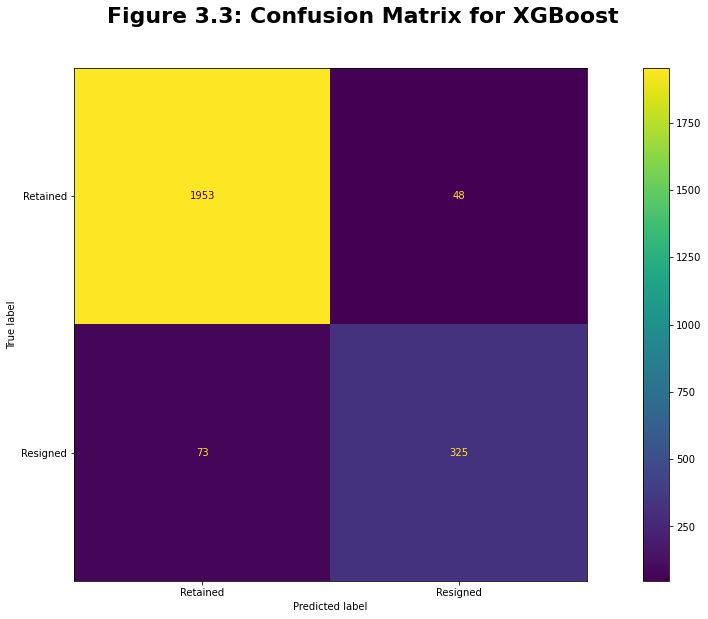

In [211]:
cm = confusion_matrix(y_test, xgb_test_preds, labels=champion.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Retained', 'Resigned'])
fig, ax = plt.subplots(figsize=(16, 9))
disp.plot(ax=ax)
fig.suptitle("Figure 3.3: Confusion Matrix for XGBoost", fontsize=22, fontweight='bold', x=0.6, horizontalalignment='center')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The model captured 325 true positives out of the total of 398 total actual positives. It failed to capture 73 actual positives (false negatives) and incorrectly labelled 48 negatives as positives (true positives). This is reflected by the overall high f1 score

#### Build Random Forest Model Tree

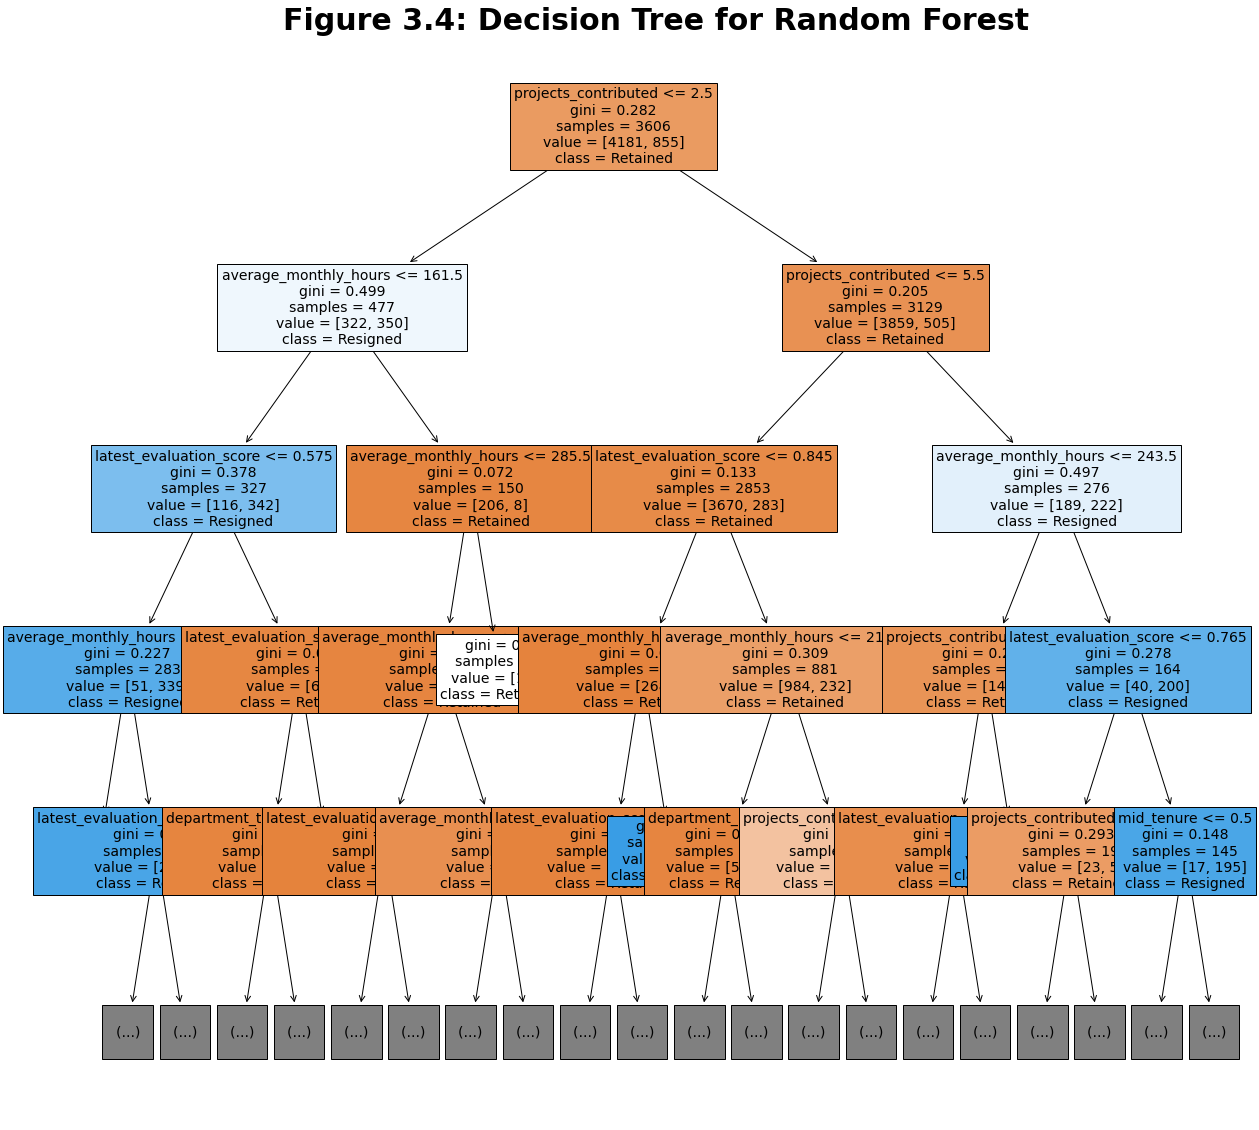

In [212]:
fig, ax = plt.subplots(figsize=(25, 20))
plot_tree(rf_cv.best_estimator_[0], max_depth=4, fontsize=14, feature_names=X.columns,class_names={0:'Retained', 1:'Resigned'}, filled=True)

ax.set_title("Figure 3.4: Decision Tree for Random Forest", fontsize=30, fontweight='bold')
plt.show()

#### Feature Importance (XGBoost Champion Model and Logistic Regression)

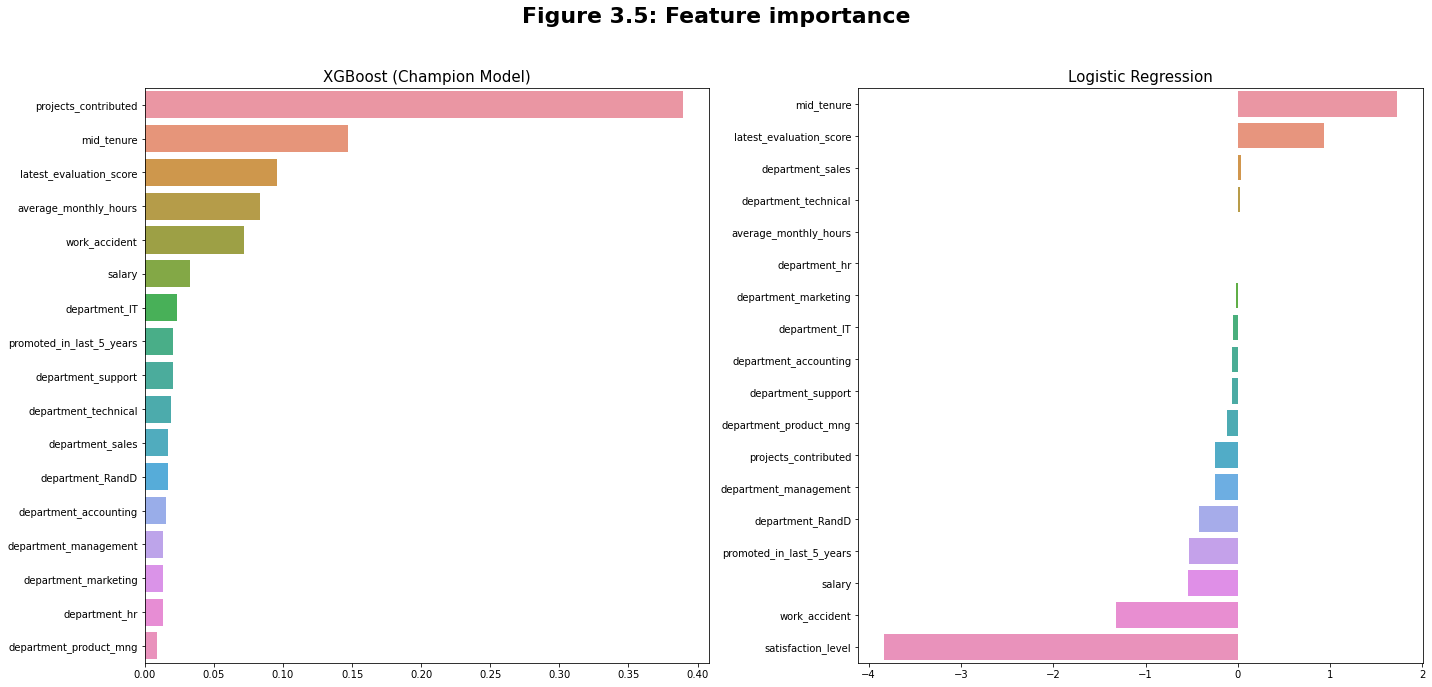

In [213]:
fig, ax = plt.subplots(1,2,figsize=(20, 10))

#Plot 1: Feature importance for XGBoost (Champion model)
importances = champion.feature_importances_
xgb_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

sns.barplot(x=xgb_importance,
            y=xgb_importance.index,
            orient='h', ax=ax[0])

ax[0].set_title('XGBoost (Champion Model)',fontsize=15)

#Plot 1: Feature importance for Logistic Regression

# Create a list of (column_name, coefficient) tuples
feature_importance = list(zip(X_train_log.columns, clf.coef_[0]))

# Sort the list by coefficient value
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

sns.barplot(x=[x[1] for x in feature_importance],
            y=[x[0] for x in feature_importance],
            orient='h', ax=ax[1])

ax[1].set_title('Logistic Regression',fontsize=15)

fig.suptitle('Figure 3.5: Feature importance',fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Relate with results from LogisticRegression

LR: Satisfaction level appears to have a strong negative relaionship followed bt work_accident. Mid tenure has a strong positive relationship followed by last evaluation. salary has a negative relationship but this is inline with highly paid, high performers being dissatisfied due to burnout

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Double-click to enter your responses here.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

[Double-click to enter your summary here.]

### Conclusion, Recommendations, Next Steps

[Double-click to enter your conclusion, recommendations, and next steps here.]